# Comparative Visual Analytics: Visualization Grammar vs. Visual Idioms

## 1. Data Ingestion & Transformation Algebra

In [ ]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm, Normalize
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9.5
plt.rcParams['ytick.labelsize'] = 9.5
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#E0E0E0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

os.makedirs('output_figures', exist_ok=True)

# 1. Ingestion: USGS Earthquakes
df_eq = pd.read_csv('earthquakes.csv')
df_eq['time'] = pd.to_datetime(df_eq['time'], errors='coerce')
df_eq['year'] = df_eq['time'].dt.year
df_eq['depth'] = df_eq['depth'].fillna(df_eq['depth'].median())

df_eq_modern = df_eq[(df_eq['year'] >= 1990) & (df_eq['year'] <= 2023)].copy()
df_eq_modern['era'] = np.where(df_eq_modern['year'] <= 2006, 'Era 1: 1990–2006', 'Era 2: 2007–2023')
n_era1 = (df_eq_modern['era'] == 'Era 1: 1990–2006').sum()
n_era2 = (df_eq_modern['era'] == 'Era 2: 2007–2023').sum()

# 2. Ingestion: Steam Marketplace
df_steam = pd.read_csv('steam-games.csv')

def parse_price(val):
    if pd.isna(val): return np.nan
    val_str = str(val).strip().lower()
    if 'free' in val_str: return 0.0
    cleaned = re.sub(r'[^\d.]', '', val_str)
    try:
        p = float(cleaned)
        return round(p / 83.0, 2) if p > 100 else p
    except: return np.nan

df_steam['price_usd'] = df_steam['discounted_price'].apply(parse_price).fillna(df_steam['original_price'].apply(parse_price))
df_games = df_steam.dropna(subset=['overall_review_%', 'overall_review_count']).copy()
df_games = df_games[df_games['overall_review_count'] >= 15].copy()
df_games['release_year'] = pd.to_datetime(df_games['release_date'], errors='coerce').dt.year

target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Casual', 'Indie']
def get_primary_genre(genre_str):
    if pd.isna(genre_str): return 'Other'
    genres = [g.strip() for g in str(genre_str).split(',')]
    for g in target_genres:
        if g in genres: return g
    return genres[0] if genres else 'Other'

df_games['primary_genre'] = df_games['genres'].apply(get_primary_genre)

df_steam_core = df_games[
    (df_games['release_year'] >= 2014) & 
    (df_games['release_year'] <= 2023) & 
    (df_games['primary_genre'].isin(target_genres))
].copy()

genre_year_summary = df_steam_core.groupby(['release_year', 'primary_genre']).agg(
    median_satisfaction=('overall_review_%', 'median'),
    title_count=('app_id', 'count'),
    total_reviews=('overall_review_count', 'sum')
).reset_index()

print(f"Dataset 1 (USGS Earthquakes): n = {len(df_eq_modern):,} events (Era 1: {n_era1:,}, Era 2: {n_era2:,})")
print(f"Dataset 2 (Steam Marketplace): N = {len(df_steam_core):,} titles across {len(genre_year_summary)} Year x Genre bins")


Dataset 1 (USGS Earthquakes): n = 5,103 events (Era 1: 2,585, Era 2: 2,518)
Dataset 2 (Steam Marketplace): N = 30,774 titles across 70 Year x Genre bins


## 2. Dataset 1: Earthquakes - Visual Idiom
**Figure 1: Global Earthquake Spatial Density Hexbin Map**


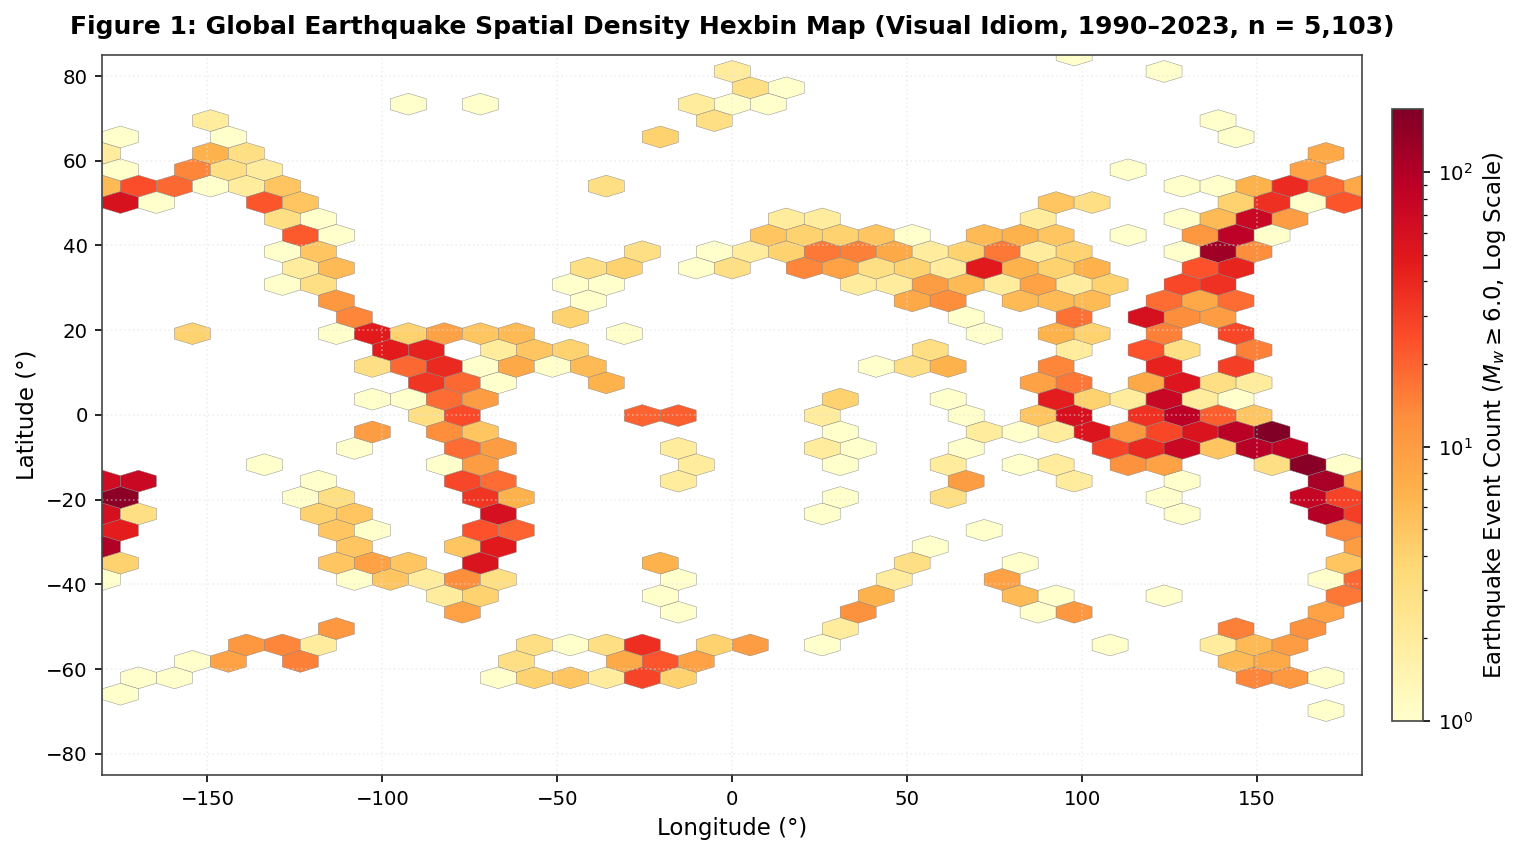

In [2]:
fig1, ax1 = plt.subplots(figsize=(11, 5.8), dpi=150)

hb = ax1.hexbin(
    df_eq_modern['longitude'], df_eq_modern['latitude'],
    gridsize=35, cmap='YlOrRd', mincnt=1,
    norm=LogNorm(vmin=1, vmax=170),
    edgecolors='gray', linewidths=0.2
)

ax1.set_title("Figure 1: Global Earthquake Spatial Density Hexbin Map (Visual Idiom, 1990–2023, n = 5,103)", pad=10, fontweight='bold')
ax1.set_xlabel("Longitude (°)")
ax1.set_ylabel("Latitude (°)")
ax1.set_xlim(-180, 180)
ax1.set_ylim(-85, 85)
ax1.grid(True, linestyle=':', alpha=0.5)

cb = fig1.colorbar(hb, ax=ax1, orientation='vertical', pad=0.02, shrink=0.85)
cb.set_label(r"Earthquake Event Count ($M_w \geq 6.0$, Log Scale)")

plt.tight_layout()
plt.savefig('output_figures/fig1_earthquake_idioms.png', bbox_inches='tight', dpi=300)
plt.show()


## 3. Dataset 1: Earthquakes - Visualization Grammar
**Figure 2: Faceted Multichannel Spatiotemporal Earthquake Composition**

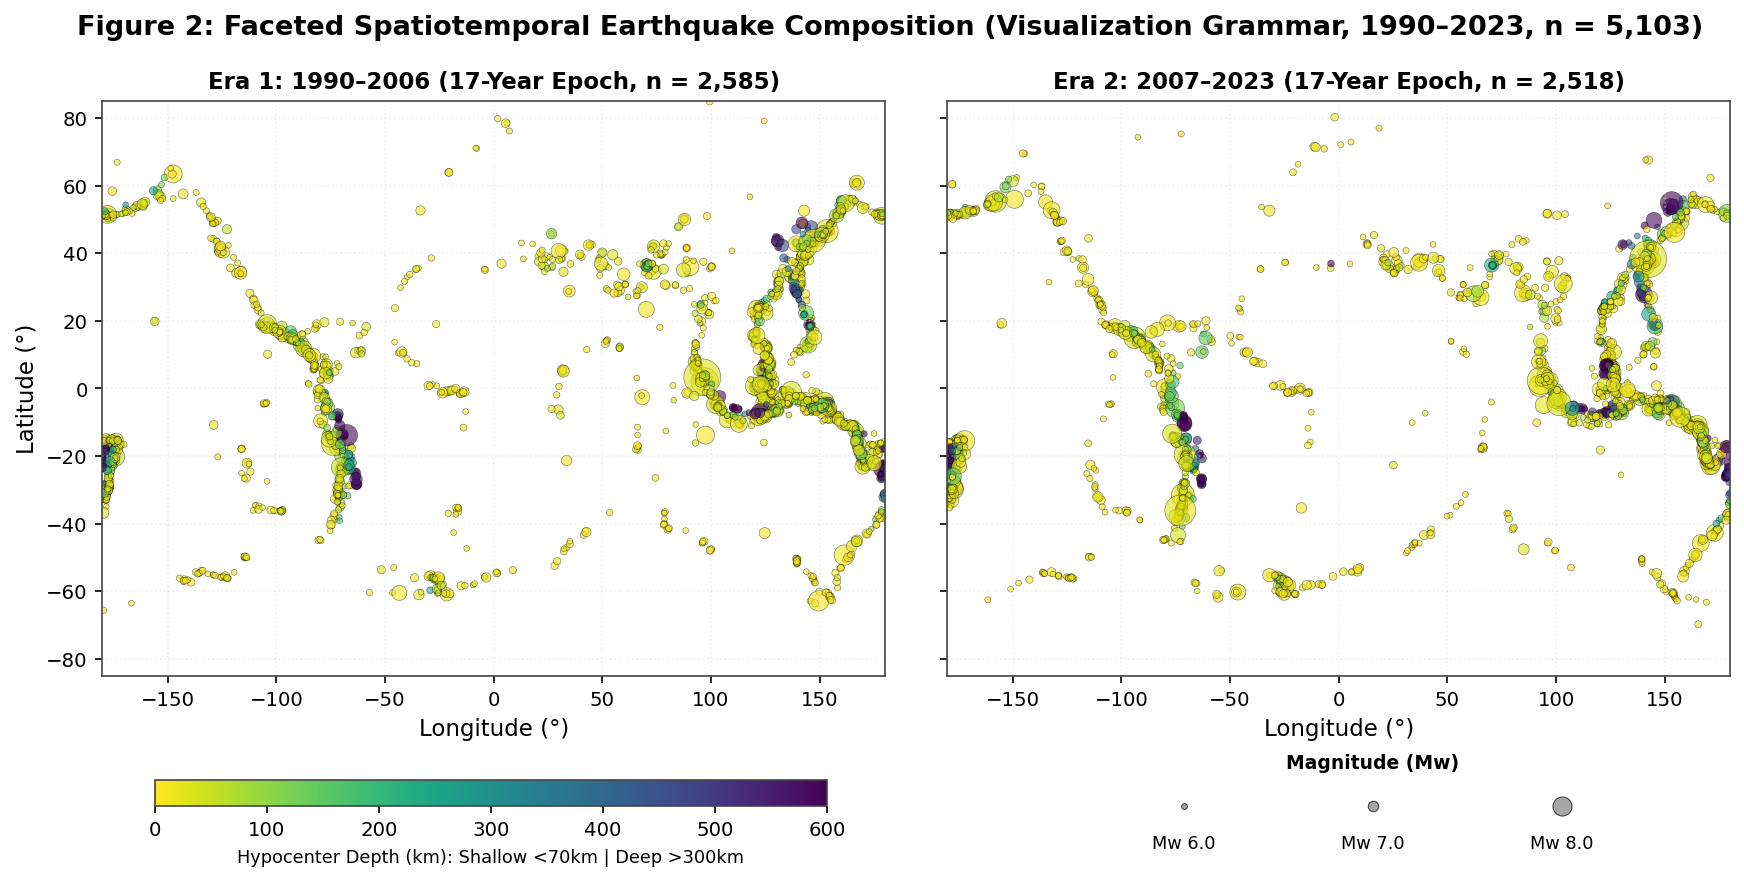

In [ ]:
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5.8), dpi=150, sharey=True)
norm_depth = Normalize(vmin=0, vmax=600)
cmap_depth = plt.cm.viridis_r

def get_point_size(mag_series):
    return np.exp((mag_series - 5.8) * 1.2) * 6

for ax, era_name, count_n in zip([ax2a, ax2b], ['Era 1: 1990–2006', 'Era 2: 2007–2023'], [n_era1, n_era2]):
    sub = df_eq_modern[df_eq_modern['era'] == era_name]
    sizes = get_point_size(sub['mag'])
    
    sc = ax.scatter(
        sub['longitude'], sub['latitude'],
        c=sub['depth'], cmap=cmap_depth, norm=norm_depth,
        s=sizes, alpha=0.6, edgecolors='black', linewidths=0.25
    )
    ax.set_title(f"{era_name} (17-Year Epoch, n = {count_n:,})", fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-85, 85)
    ax.set_xlabel("Longitude (°)")
    ax.grid(True, linestyle=':', alpha=0.5)

ax2a.set_ylabel("Latitude (°)")

cbar_ax = fig2.add_axes([0.15, 0.07, 0.32, 0.03])
cb2 = fig2.colorbar(plt.cm.ScalarMappable(norm=norm_depth, cmap=cmap_depth), cax=cbar_ax, orientation='horizontal')
cb2.set_label("Hypocenter Depth (km): Shallow <70km | Deep >300km", fontsize=8.5)

# Magnitude Legend (Bottom-Right) - Fixed Alignment & Scale
legend_ax = fig2.add_axes([0.58, 0.03, 0.30, 0.09])
legend_ax.axis('off')
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)

legend_ax.text(0.5, 0.88, "Magnitude (Mw)", ha='center', va='bottom', fontsize=9, fontweight='bold')
for i, (m, label) in enumerate(zip([6.0, 7.0, 8.0], ["Mw 6.0", "Mw 7.0", "Mw 8.0"])):
    s_val = get_point_size(np.array([m]))[0]
    x_pos = 0.20 + i * 0.30
    legend_ax.scatter([x_pos], [0.45], s=s_val, c='gray', alpha=0.7, edgecolors='black', linewidths=0.5)
    legend_ax.text(x_pos, 0.08, label, ha='center', va='top', fontsize=8.5)

fig2.suptitle("Figure 2: Faceted Spatiotemporal Earthquake Composition (Visualization Grammar, 1990–2023, n = 5,103)", y=0.98, fontweight='bold')
plt.subplots_adjust(bottom=0.22, top=0.88, wspace=0.08)
plt.savefig('output_figures/fig2_earthquake_grammar.png', bbox_inches='tight', dpi=300)
plt.show()


## 4. Dataset 2: Steam Games - Visual Idiom
**Figure 3: Genre $\times$ Release Year Satisfaction Heatmap**


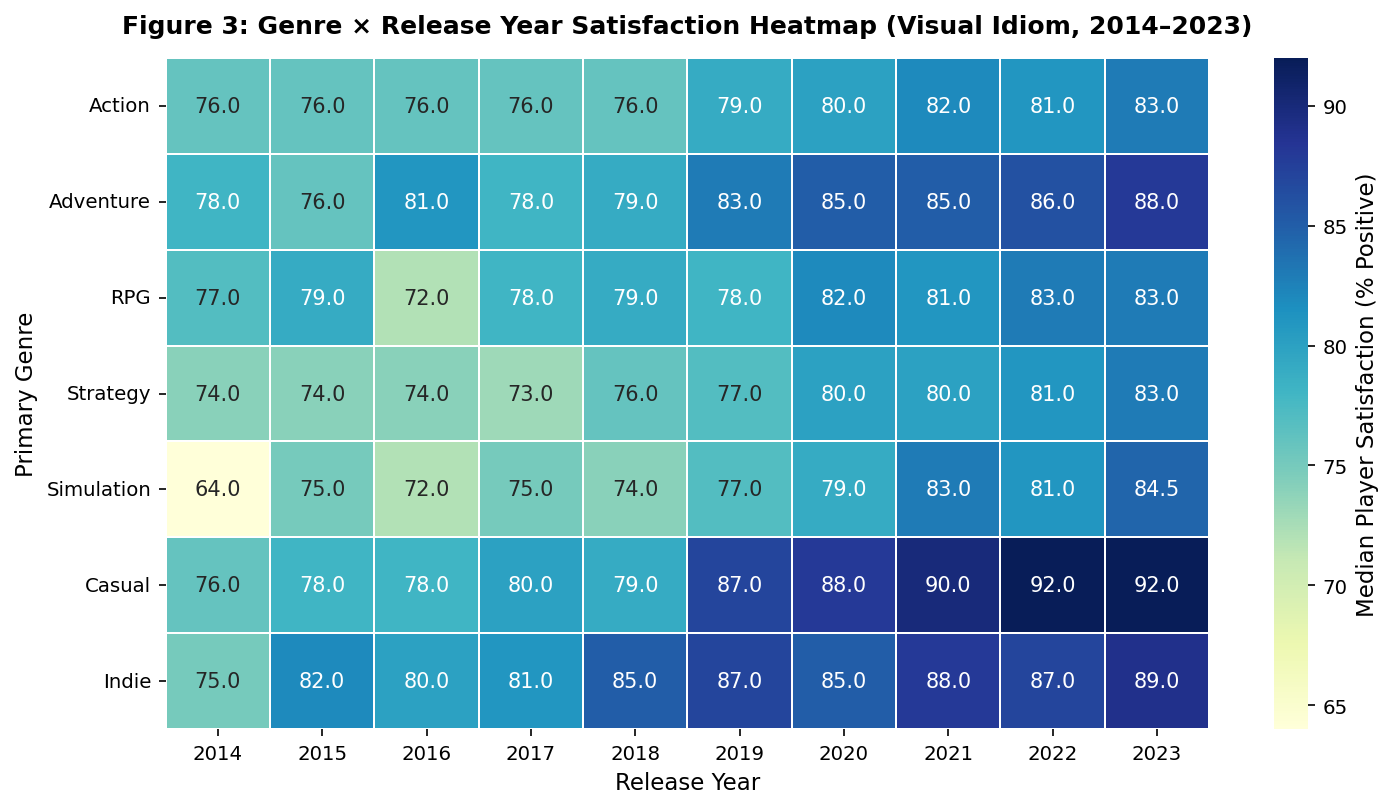

In [4]:
fig3, ax3 = plt.subplots(figsize=(10, 5.5), dpi=150)

heatmap_matrix = genre_year_summary.pivot(
    index='primary_genre', columns='release_year', values='median_satisfaction'
).reindex(target_genres)

sns.heatmap(
    heatmap_matrix, cmap='YlGnBu', annot=True, fmt=".1f",
    cbar_kws={'label': 'Median Player Satisfaction (% Positive)'},
    linewidths=0.8, linecolor='white', ax=ax3, vmin=64.0, vmax=92.0
)

ax3.set_title("Figure 3: Genre × Release Year Satisfaction Heatmap (Visual Idiom, 2014–2023)", pad=12, fontweight='bold')
ax3.set_xlabel("Release Year")
ax3.set_ylabel("Primary Genre")
ax3.set_xticklabels([str(int(c)) for c in heatmap_matrix.columns])

plt.tight_layout()
plt.savefig('output_figures/fig3_steam_idioms.png', bbox_inches='tight', dpi=300)
plt.show()


## 5. Dataset 2: Steam Games - Visualization Grammar
**Figure 4: Layered Genre Evolution & Title Volume Composition**


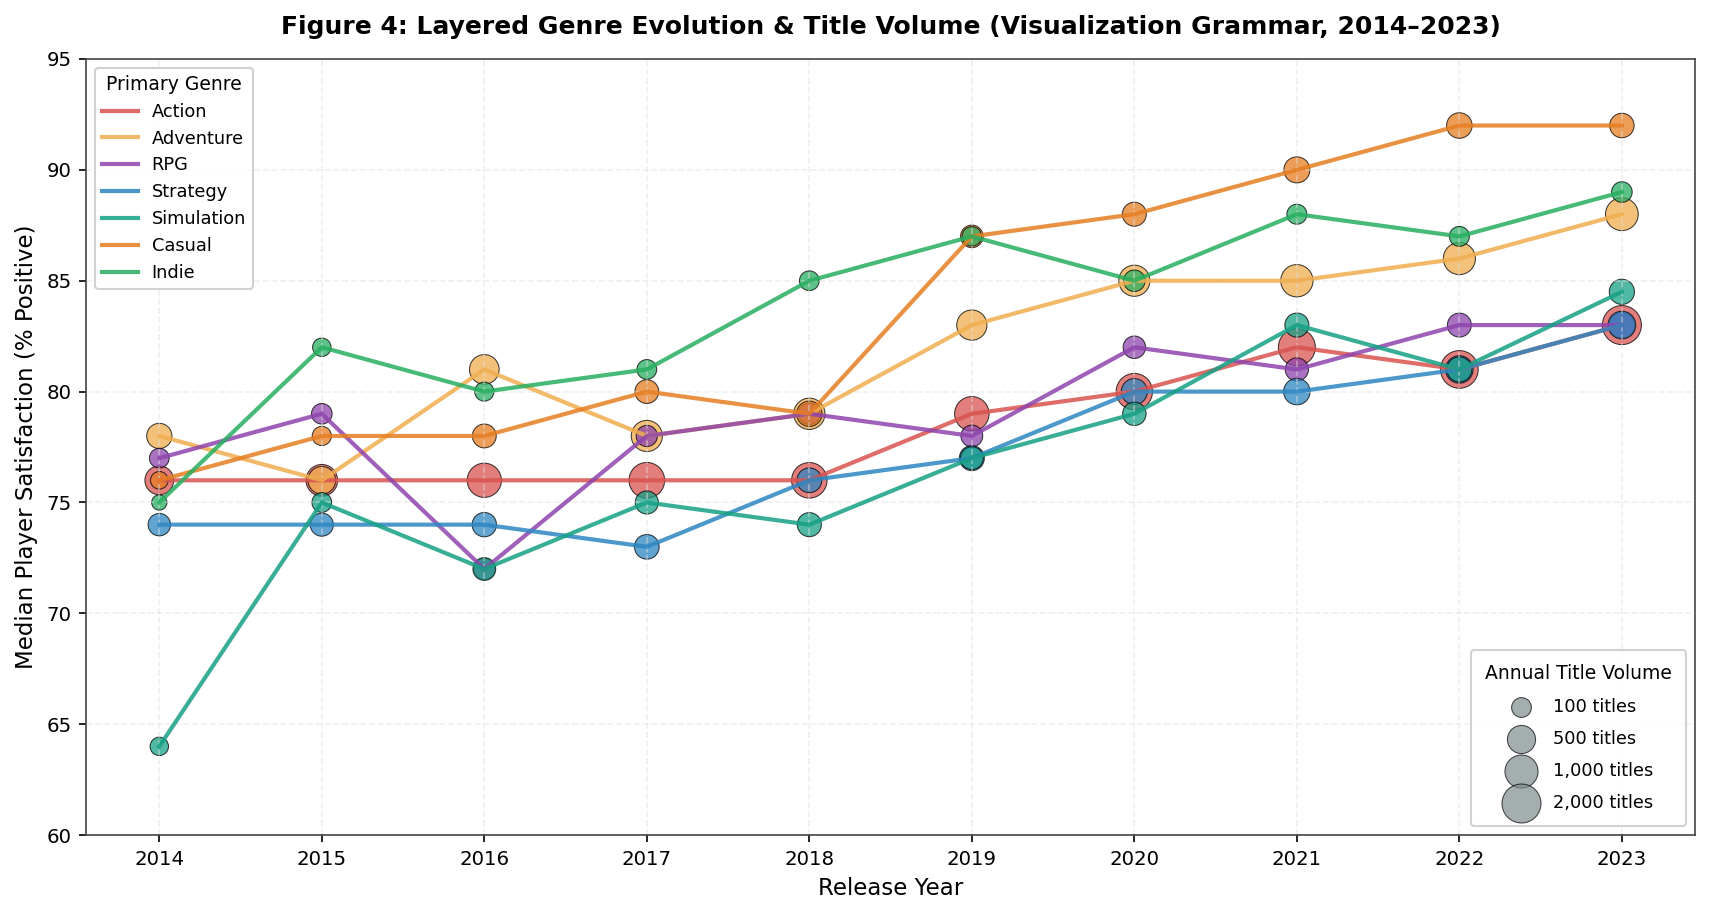

In [5]:
fig4, ax4 = plt.subplots(figsize=(11.5, 6.2), dpi=150)

palette_genres = {
    'Action': '#D9534F', 'Adventure': '#F0AD4E', 'RPG': '#8E44AD',
    'Strategy': '#2E86C1', 'Simulation': '#16A085', 'Casual': '#E67E22', 'Indie': '#27AE60'
}

for genre in target_genres:
    sub = genre_year_summary[genre_year_summary['primary_genre'] == genre].sort_values('release_year')
    color = palette_genres[genre]
    ax4.plot(sub['release_year'], sub['median_satisfaction'], color=color, linewidth=2.0, alpha=0.85, label=genre)
    point_sizes = 15 + np.sqrt(sub['title_count']) * 7.5
    ax4.scatter(sub['release_year'], sub['median_satisfaction'], s=point_sizes, color=color, alpha=0.75, edgecolors='black', linewidths=0.5)

ax4.set_title("Figure 4: Layered Genre Evolution & Title Volume (Visualization Grammar, 2014–2023)", pad=12, fontweight='bold')
ax4.set_xlabel("Release Year")
ax4.set_ylabel("Median Player Satisfaction (% Positive)")
ax4.set_ylim(60, 95)
ax4.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax4.grid(True, linestyle='--', alpha=0.5)

legend1 = ax4.legend(title="Primary Genre", loc='upper left', frameon=True, framealpha=0.9, fontsize=8.5, title_fontsize=9)
ax4.add_artist(legend1)

vol_samples = [100, 500, 1000, 2000]
vol_handles = [
    plt.scatter([], [], s=15 + np.sqrt(v)*7.5, c='#7F8C8D', alpha=0.7, edgecolors='black', linewidths=0.5)
    for v in vol_samples
]
vol_labels = [f"{v:,} titles" for v in vol_samples]

legend2 = ax4.legend(
    vol_handles, vol_labels, title="Annual Title Volume",
    loc='lower right', frameon=True, framealpha=0.9, fontsize=8.5, title_fontsize=9,
    labelspacing=0.8, borderpad=0.8
)

plt.tight_layout()
plt.savefig('output_figures/fig4_steam_grammar.png', bbox_inches='tight', dpi=300)
plt.show()
